# Single flow-curve analysis with `rheofit`

Fit one steady-shear flow curve — stress $\sigma$ vs shear rate $\dot\gamma$ — to every model in the
`rheofit` library, compare them with parsimony criteria that guard against overfitting, and build a
scorecard for the winning model.

## Cell 1 — API tour

A cheat-sheet of the public API. Nothing is saved unless `analyze(..., output=...)` is called.

| Call | What it does |
| --- | --- |
| `rheofit.list_models()` | names of the available models |
| `rheofit.demo_source()` | path to the bundled demo JSON (structured shampoo) |
| `rheofit.print_steps(f)` | lists the measurement steps inside a file |
| `rheofit.load_step(f, i)` | returns one step as a `DataFrame` |
| `rheofit.fit(df, model)` | robust multi-start fit → dict with `params`, `redchi`, `cond`, `notes` |
| `rheofit.analyze(...)` | load → fit → summarise → save PNG/CSV/PPTX in one call |

`effort` controls the global search: `"fast"` (32 Sobol starts), `"normal"` (128) or `"thorough"`
(512 + differential evolution for the higher-dimensional models).


In [ ]:
import rheofit

rheofit.list_models()
# ['carreau', 'carreau_carreau', 'herschel_bulkley', 'power_law', 'tc', 'tc_carreau', 'tccc']

filename = rheofit.demo_source()  # or rheofit.demo_source() for bundled demo JSON
rheofit.demo_source()         # bundled demo JSON, resolved inside the package
rheofit.print_steps(filename)            # which steps exist (0-based ResultsSteps index)

df = rheofit.load_step(filename, 0)      # one step as a DataFrame
res = rheofit.fit(df, "tc_carreau", effort="thorough")
res["params"]   # {'sigma_y': {'value': ..., 'stderr': ...}, ...}
res["redchi"], res["notes"]

a = rheofit.analyze(                          # load -> fit -> summarise -> save
    filename, steps=[0, 2], model="tc_carreau", labels=["25C", "40C"], output="png_csv",
    results_base=".",                         # write results/ next to this notebook
)
a.summary      # tidy DataFrame: step, parameter, value, stderr, rel_error_pct, redchi2, quality
a.outputs      # saved PNG / CSV / PPTX paths


## Cell 2 — fit every model, screen for overfitting, score the winner

This cell does four things:

1. Loads step 0 of the demo file and fits **all seven models** at `effort="thorough"`.
2. Draws the flow-curve fit for each one (stress + viscosity overlay, with a relative-residual panel).
3. Computes parsimony and identifiability diagnostics, then ranks the models.
4. Plots the parameter scorecard for the best *parsimonious* model.

### The model library

Every model is fitted with a **relative-weighted** objective,

$$r_i = \frac{\sigma_\text{model}(\dot\gamma_i) - \sigma_i}{|\sigma_i|},$$

so each decade of stress contributes equally and $\chi^2_\nu$ is dimensionless and comparable across
models. The models form a *nesting ladder* — each child reduces exactly to its parent for particular
parameter values, which is what makes the F-test below valid.

#### Viscous models (no yield stress)

**`power_law`** — $p=2$, parent: —

$$\sigma = K\,\dot\gamma^{\,n}$$

Pure shear thinning for $n<1$. No zero-shear plateau, so the viscosity diverges as $\dot\gamma\to0$.

**`carreau`** — $p=3$, parent: —

$$\sigma = \eta_0\,\dot\gamma\left[1+(\lambda\dot\gamma)^2\right]^{\frac{n-1}{2}}$$

Newtonian plateau $\eta_0$ below $\dot\gamma\sim1/\lambda$, power-law thinning above it. Here $n$ is the
only *free* exponent in the library (bounded to $0.01\le n\le1$); it is the high-rate slope of the
stress, $\sigma\sim\dot\gamma^{\,n}$. The limit $n\to0$ is the **stress plateau expected for worm-like
micelles**, where shear banding pins the stress at a constant value while the rate increases.

**`carreau_carreau`** — $p=4$, parent: `carreau`

$$\sigma = \eta_{0,1}\,\dot\gamma\left[1+(\lambda_1\dot\gamma)^2\right]^{-1/2}
        + \eta_{0,2}\,\dot\gamma\left[1+(\lambda_2\dot\gamma)^2\right]^{-1/4}$$

Two thinning modes whose exponents are **fixed rather than fitted**, each chosen for a specific
physical mechanism — this is what keeps a two-mode model at only four parameters:

| Mode | Exponent | High-rate limit | Physical origin |
| --- | --- | --- | --- |
| 1 | $-1/2$, i.e. $n_1=0$ | $\sigma\sim\dot\gamma^{\,0}$ (stress plateau), $\eta\sim\dot\gamma^{-1}$ | **worm-like micelles**: shear banding clamps the stress |
| 2 | $-1/4$, i.e. $n_2=1/2$ | $\sigma\sim\dot\gamma^{\,1/2}$, $\eta\sim\dot\gamma^{-1/2}$ | **polymer–surfactant interaction or branched WLM**: the extra network relaxation pathway softens the plateau |

Only the amplitudes $\eta_{0,i}$ and the onset times $\lambda_i$ are fitted, so each mode contributes
two well-conditioned parameters instead of three.

#### Yield-stress models

**`herschel_bulkley`** — $p=3$, parent: `power_law`

$$\sigma = \sigma_y + K\,\dot\gamma^{\,n}$$

The classic yield-stress fluid; reduces to `power_law` as $\sigma_y\to0$.

**`tc`** (Three-Component) — $p=3$, parent: —

Its exponent is fixed at $-1/2$ ($n=0$), the worm-like-micelle stress plateau.

**`tccc`** — $p=6$, parent: `tc_carreau`

$$\sigma = \sigma_y + \sigma_y\left(\frac{\dot\gamma}{\dot\gamma_c}\right)^{1/2}
        + \eta_{0,1}\,\dot\gamma\left[1+(\lambda_1\dot\gamma)^2\right]^{-1/2}
        + \eta_{0,2}\,\dot\gamma\left[1+(\lambda_2\dot\gamma)^2\right]^{-1/4}$$
The richest model: a yield stress plus both fixed-exponent Carreau modes — the $n=0$ WLM plateau and
the $n=1/2$ polymer–surfactant / branched-WLM mode. With six parameters it is the most likely to
**overfit**, which is exactly what the diagnostics below are designed to catch.

### Why $\chi^2_\nu$ alone is not enough

A model with more parameters will almost always reach a lower residual sum of squares
$\text{SSR}=\sum_i r_i^2$, even when the extra flexibility is only fitting noise. The cell therefore
reports five complementary criteria:

| Metric | Definition | Overfitting signal |
| --- | --- | --- |
| **AICc** | $n\ln(\text{SSR}/n) + 2k + \dfrac{2k(k+1)}{n-k-1}$, with $k=p+1$ | $\Delta\text{AICc}>2$ vs the best model ⇒ the extra parameters do not pay for themselves |
| **BIC** | $n\ln(\text{SSR}/n) + k\ln n$ | Same idea with a harsher $\ln n$ penalty |
| **Nested F-test** | $F=\dfrac{(\text{SSR}_\text{parent}-\text{SSR})/(p-p_\text{parent})}{\text{SSR}/(n-p)}$ | $p\text{-value}>0.05$ ⇒ the child is not a significant improvement over its parent |
| **MaxRelErr% / WeakParams** | $100\,\lvert\sigma_\theta/\theta\rvert$ per parameter | $>100\%$ ⇒ the parameter is not identifiable from this data |
| **Cond** | condition number of the Jacobian | $>10^{12}$ ⇒ near-degenerate, parameters are trading off against each other |

A sixth metric, the **Wald–Wolfowitz runs $z$**, checks the *shape* of the residuals rather than
their size: it counts sign changes in the residual sequence and compares that to the number expected
from random scatter. Strongly negative $z$ means long runs of same-sign residuals, i.e. systematic
misfit (**under**-fitting); $z\approx0$ means the residuals look like noise, which is what a
correctly-specified model should produce.

The winner is the lowest-AICc model that trips **none** of the flags, falling back to plain lowest
AICc if every candidate is flagged.



| **MaxRelErr% / WeakParams** | $100\,\lvert\sigma_\theta/\theta\rvert$ per parameter | $>100\%$ ⇒ the parameter is not identifiable from this data |

| **Cond** | condition number of the Jacobian | $>10^{12}$ ⇒ near-degenerate, parameters are trading off against each other |AICc if every candidate is flagged.

The winner is the lowest-AICc model that trips **none** of the flags, falling back to plain lowest

A sixth metric, the **Wald–Wolfowitz runs $z$**, checks the *shape* of the residuals rather than

their size: it counts sign changes in the residual sequence and compares that to the number expectedcorrectly-specified model should produce.

from random scatter. Strongly negative $z$ means long runs of same-sign residuals, i.e. systematicmisfit (**under**-fitting); $z\approx0$ means the residuals look like noise, which is what a

Fitting carreau...


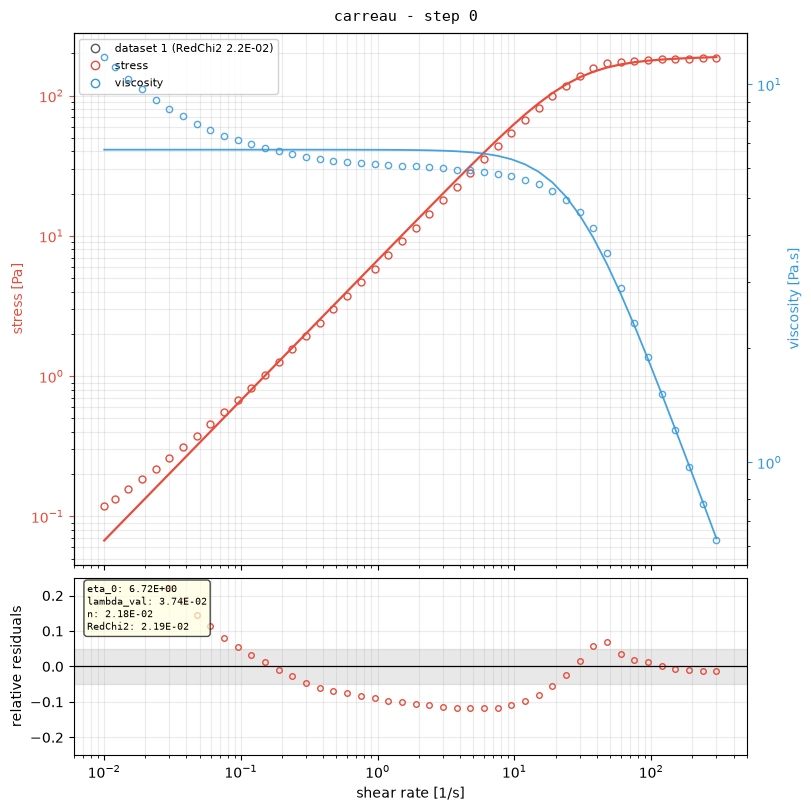

Fitting carreau_carreau...


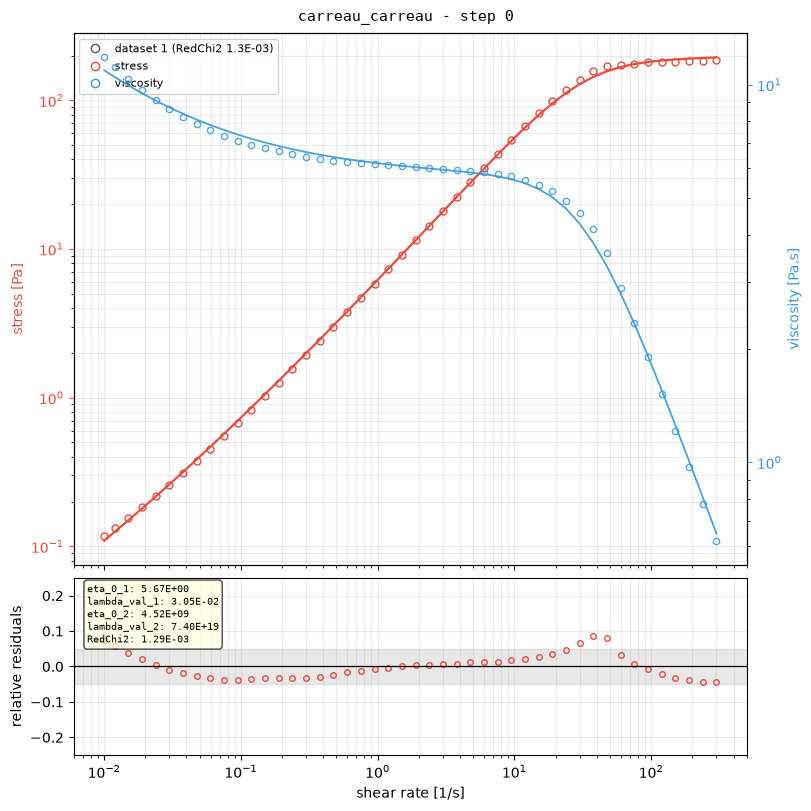

Fitting herschel_bulkley...


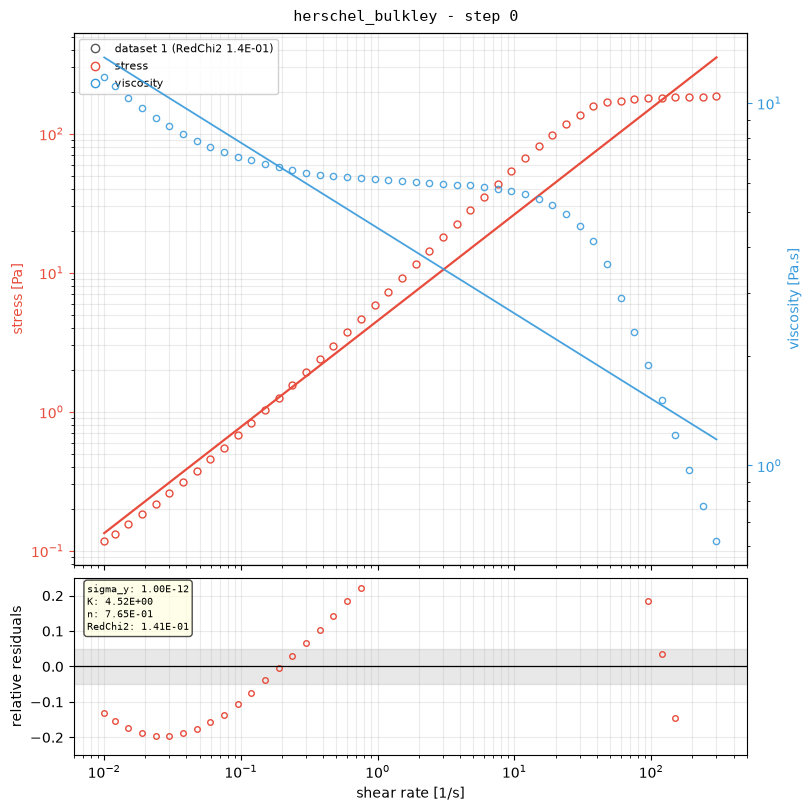

Fitting power_law...


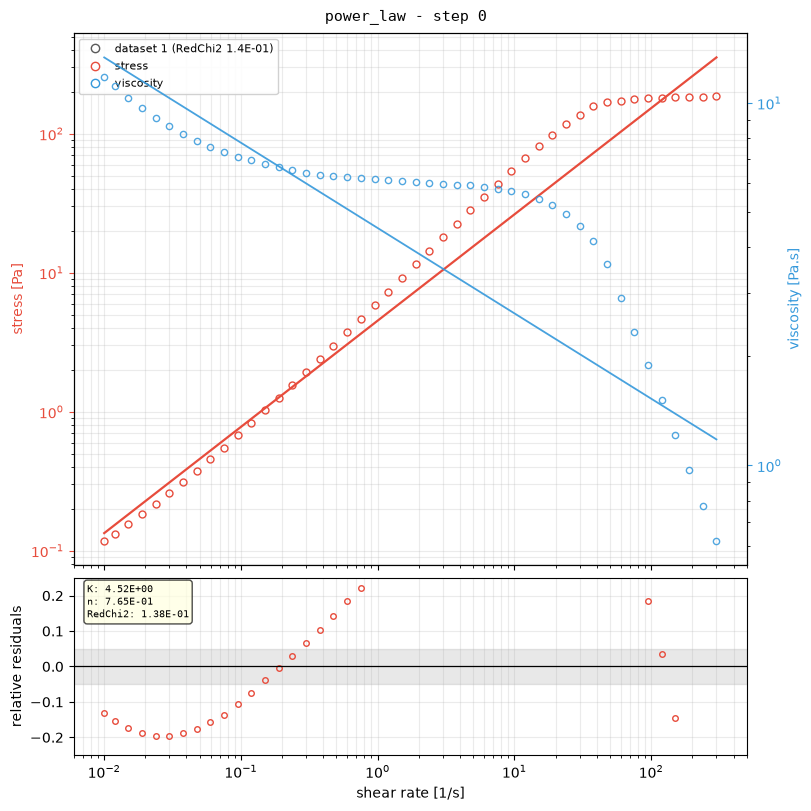

Fitting tc...


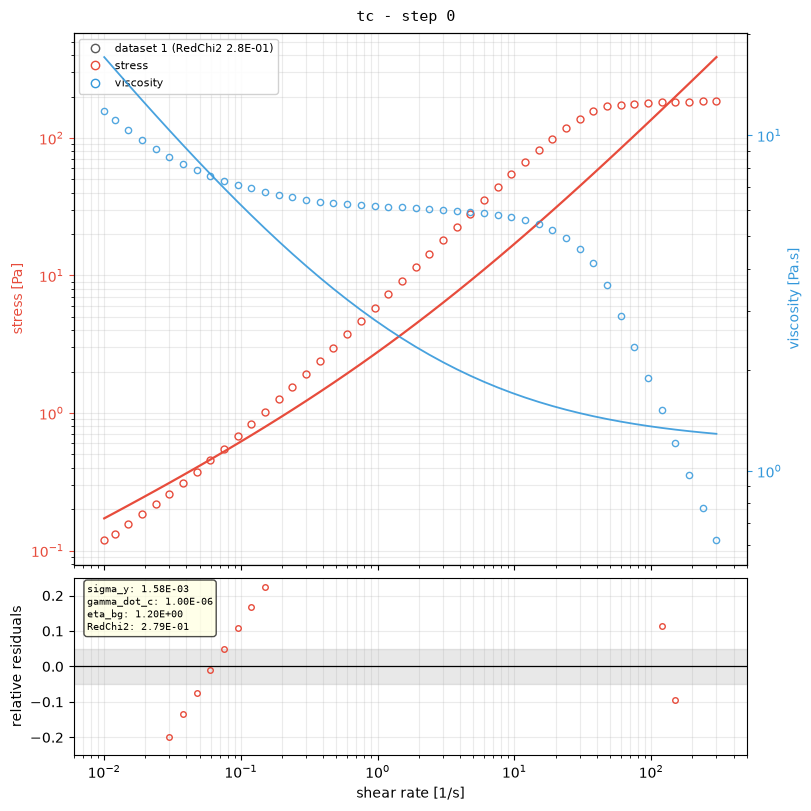

Fitting tc_carreau...


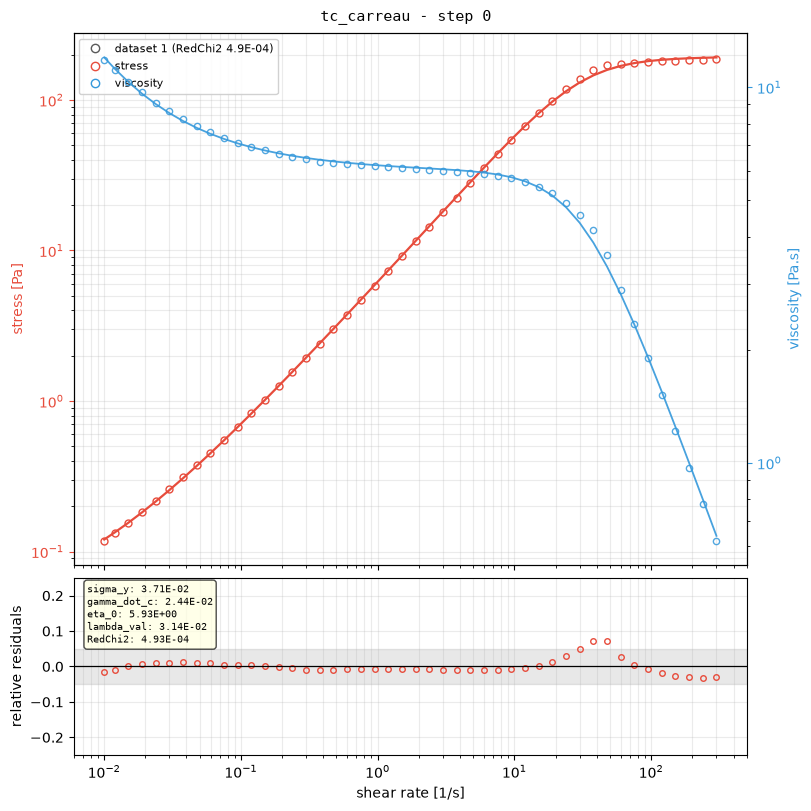

Fitting tccc...


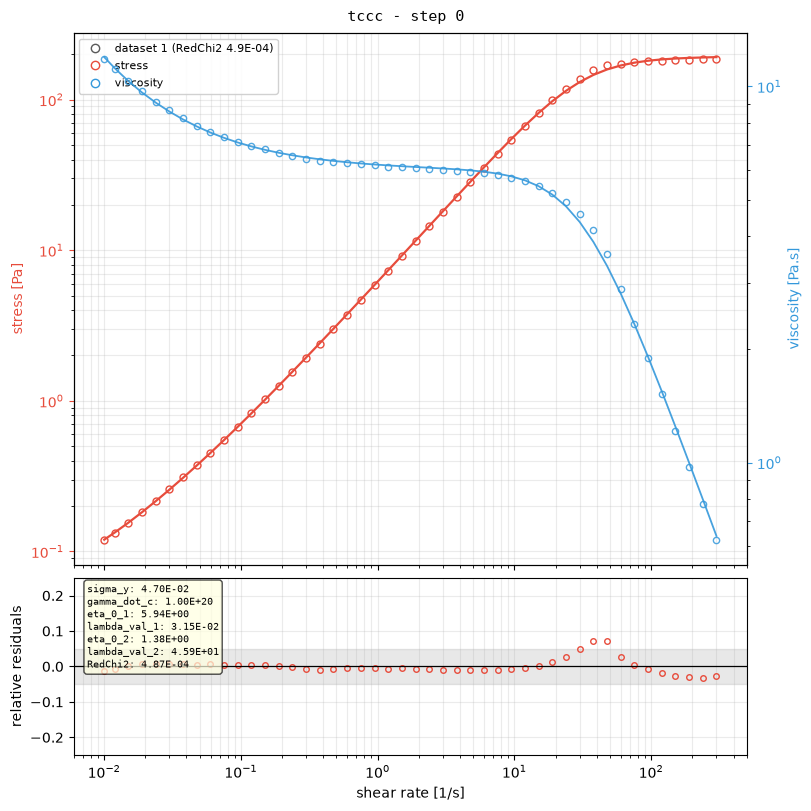


Model comparison (ranked by AICc - lower is better, penalises extra parameters):


,Model,Params,RedChi2,AICc,dAICc,BIC,F-test p vs parent,MaxRelErr%,Cond,RunsZ,Overfit flags
0,tc_carreau,4,4.925e-04,-343.0,0.0,-335.4,0.000,54.8,1.6e+02,-5.63,OK
1,tccc,6,4.869e-04,-340.3,2.7,-330.5,0.299,194.8,8.1e+17,-5.65,2 weakly identified; near-degenerate Jacobian;...
2,carreau_carreau,4,1.294e-03,-298.6,44.4,-290.9,0.000,2809284245.7,5.4e+09,-5.96,2 weakly identified; dAICc>2
3,carreau,3,2.186e-02,-170.0,173.0,-163.6,,417.4,1.3e+01,-5.95,1 weakly identified; dAICc>2
4,power_law,2,1.381e-01,-86.6,256.5,-81.6,,5.9,1.6e+00,-6.24,dAICc>2
5,herschel_bulkley,3,1.413e-01,-84.2,258.9,-77.8,1.000,6.0,inf,-6.24,near-degenerate Jacobian; no gain over parent ...
6,tc,3,2.789e-01,-52.9,290.2,-46.5,,10724.4,1.0e+03,-6.16,2 weakly identified; dAICc>2



Best parsimonious model: tc_carreau. Generating scorecard plot...


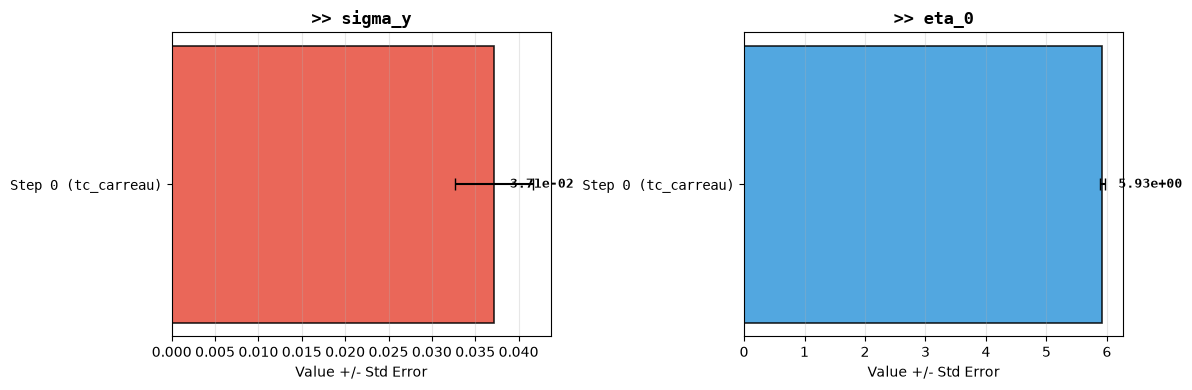

In [6]:
import numpy as np
import pandas as pd
import rheofit
import matplotlib.pyplot as plt
from scipy.stats import f as f_dist
from IPython.display import display

# ── Load demo data ────────────────────────────────────────────────────────────
filename = rheofit.demo_source()
df = rheofit.load_step(filename, 0)

# ── Fit every model and show its flow-curve fit ───────────────────────────────
all_fits = {}
for model_name in rheofit.list_models():
    print(f"Fitting {model_name}...")
    res = rheofit.fit(df, model_name, effort="thorough")
    all_fits[model_name] = res
    rheofit.report.plot_fit(res, title=f"{model_name} - step 0")
    plt.show()


# ── Overfitting / parsimony diagnostics ───────────────────────────────────────
def diagnostics(res):
    """Information criteria and identifiability metrics from a fit result.

    The objective is relative-weighted, r = (y_fit - y)/|y|, so SSR is
    dimensionless and comparable across models fitted to the same data.
    """
    y, yfit = np.asarray(res["y_data"], float), np.asarray(res["y_fit"], float)
    r = (yfit - y) / np.abs(y)
    n = r.size
    p = len(res["params"])
    ssr = float(np.sum(r**2))

    # Gaussian log-likelihood up to a constant -> AIC/BIC; k counts sigma too
    k = p + 1
    aic = n * np.log(ssr / n) + 2 * k
    aicc = aic + (2 * k * (k + 1) / (n - k - 1)) if n - k - 1 > 0 else np.inf
    bic = n * np.log(ssr / n) + k * np.log(n)

    # identifiability: parameters whose 1-sigma error swamps their value
    rel_err = [
        abs(v["stderr"] / v["value"]) * 100
        for v in res["params"].values()
        if np.isfinite(v["stderr"]) and v["value"] != 0
    ]
    max_rel = max(rel_err) if rel_err else np.inf
    n_weak = sum(e > 100 for e in rel_err)

    # Wald-Wolfowitz runs test: too few sign changes => systematic misfit
    signs = np.sign(r[r != 0])
    runs = 1 + int(np.sum(signs[1:] != signs[:-1])) if signs.size else 0
    n_pos, n_neg = int(np.sum(signs > 0)), int(np.sum(signs < 0))
    if n_pos and n_neg:
        mu = 2 * n_pos * n_neg / (n_pos + n_neg) + 1
        var = (mu - 1) * (mu - 2) / (n_pos + n_neg - 1)
        runs_z = (runs - mu) / np.sqrt(var) if var > 0 else np.nan
    else:
        runs_z = np.nan

    return {
        "n": n, "p": p, "SSR": ssr, "AICc": aicc, "BIC": bic,
        "MaxRelErr%": max_rel, "WeakParams": n_weak,
        "Cond": res["cond"], "RunsZ": runs_z,
    }


rows = []
for name, res in all_fits.items():
    d = diagnostics(res)
    parent = rheofit.model_info(name)["parent"]

    # nested F-test: is the extra flexibility over the parent statistically earned?
    f_p = np.nan
    if parent in all_fits:
        dp = diagnostics(all_fits[parent])
        dof_num, dof_den = d["p"] - dp["p"], d["n"] - d["p"]
        if dof_num > 0 and dof_den > 0 and d["SSR"] > 0:
            f_stat = ((dp["SSR"] - d["SSR"]) / dof_num) / (d["SSR"] / dof_den)
            f_p = float(f_dist.sf(f_stat, dof_num, dof_den)) if f_stat > 0 else 1.0

    rows.append({
        "Model": name, "Params": d["p"], "RedChi2": res["redchi"],
        "AICc": d["AICc"], "BIC": d["BIC"], "F-test p vs parent": f_p,
        "MaxRelErr%": d["MaxRelErr%"], "WeakParams": d["WeakParams"],
        "Cond": d["Cond"], "RunsZ": d["RunsZ"],
        "Success": res.get("success", True),
    })

df_results = pd.DataFrame(rows).sort_values("AICc").reset_index(drop=True)
df_results["dAICc"] = df_results["AICc"] - df_results["AICc"].min()


# overfitting verdict: extra parameters that buy neither AICc nor identifiability
def verdict(row):
    flags = []
    if row["WeakParams"] > 0:
        flags.append(f"{row['WeakParams']} weakly identified")
    if row["Cond"] > 1e12:
        flags.append("near-degenerate Jacobian")
    if np.isfinite(row["F-test p vs parent"]) and row["F-test p vs parent"] > 0.05:
        flags.append("no gain over parent (F p>0.05)")
    if row["dAICc"] > 2:
        flags.append("dAICc>2")
    return "OK" if not flags else "; ".join(flags)


df_results["Overfit flags"] = df_results.apply(verdict, axis=1)

print("\nModel comparison (ranked by AICc - lower is better, penalises extra parameters):")
_fmt = {
    "RedChi2": "{:.3e}", "AICc": "{:.1f}", "dAICc": "{:.1f}", "BIC": "{:.1f}",
    "F-test p vs parent": "{:.3f}", "MaxRelErr%": "{:.1f}", "Cond": "{:.1e}",
    "RunsZ": "{:.2f}",
}
_cols = [
    "Model", "Params", "RedChi2", "AICc", "dAICc", "BIC",
    "F-test p vs parent", "MaxRelErr%", "Cond", "RunsZ", "Overfit flags",
]
df_display = df_results[_cols].copy()
for col, spec in _fmt.items():
    df_display[col] = df_display[col].map(lambda v, s=spec: "" if pd.isna(v) else s.format(v))
display(df_display)

# best = lowest AICc among models with no overfitting flags, else lowest AICc
clean = df_results[df_results["Overfit flags"] == "OK"]
best_model = (clean if not clean.empty else df_results).iloc[0]["Model"]
print(f"\nBest parsimonious model: {best_model}. Generating scorecard plot...")

# ── Scorecard for the best model ──────────────────────────────────────────────
res_dict = {f"Step 0 ({best_model})": all_fits[best_model]}
params = rheofit.model_info(best_model)["scorecard_params"]
fig, _, _ = rheofit.report.plot_scorecard(res_dict, params)
plt.show()
